# Uber Ride Booking Data Analysis using Python

## Objective

The objective of this project is to analyze Uber ride booking data to understand customer booking patterns, peak booking hours, payment preferences, booking status, and driver ratings. The insights generated from this analysis can help improve business decisions and operational efficiency.

## Business Problem

The ride-sharing company wants to understand customer behavior and booking trends.
The company wants answers to questions like:

* When do customers book the most rides?
*  Which payment method is used most?
*  How many rides are completed or cancelled?
*  Which hours of the day are busiest?
*  How are drivers rated by customers?

## Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# Load the dataset
df = pd.read_csv("rideBookings.csv")

In [34]:
df.head()


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
# Convert Date column to datetime (if not already done)
df['Date'] = pd.to_datetime(df['Date'])

# Count trips per day
daily_trips = df.groupby(df['Date'].dt.date).size()

In [5]:
trip_counts = daily_trips.values
print("Mean trips per day:", np.mean(trip_counts))
print("Max trips in a day:", np.max(trip_counts))
print("Standard deviation:", np.std(trip_counts))


Mean trips per day: 410.958904109589
Max trips in a day: 462
Standard deviation: 20.60884127080054


In [6]:
df.shape


(150000, 21)

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[us]
 1   Time                               150000 non-null  str           
 2   Booking ID                         150000 non-null  str           
 3   Booking Status                     150000 non-null  str           
 4   Customer ID                        150000 non-null  str           
 5   Vehicle Type                       150000 non-null  str           
 6   Pickup Location                    150000 non-null  str           
 7   Drop Location                      150000 non-null  str           
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by Customer    

In [39]:
df['Pickup Location'] = df['Pickup Location'].fillna("Unknown")

In [40]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [41]:
df.describe()

,date,avg_vtat,avg_ctat,cancelled_rides_by_customer,cancelled_rides_by_driver,incomplete_rides,booking_value,ride_distance,driver_ratings,customer_rating
count,150000,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,2024-06-30 16:42:40.320000,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
min,2024-01-01 00:00:00,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,2024-03-31 00:00:00,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,2024-07-01 00:00:00,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,2024-09-30 00:00:00,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,2024-12-30 00:00:00,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000
std,NaN,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819


In [42]:
print(df.columns)


Index(['date', 'time', 'booking_id', 'booking_status', 'customer_id',
       'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat',
       'avg_ctat', 'cancelled_rides_by_customer',
       'reason_for_cancelling_by_customer', 'cancelled_rides_by_driver',
       'driver_cancellation_reason', 'incomplete_rides',
       'incomplete_rides_reason', 'booking_value', 'ride_distance',
       'driver_ratings', 'customer_rating', 'payment_method'],
      dtype='str')


In [43]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [44]:
daily_trips = df.groupby(df['date'].dt.date)['booking_id'].count()

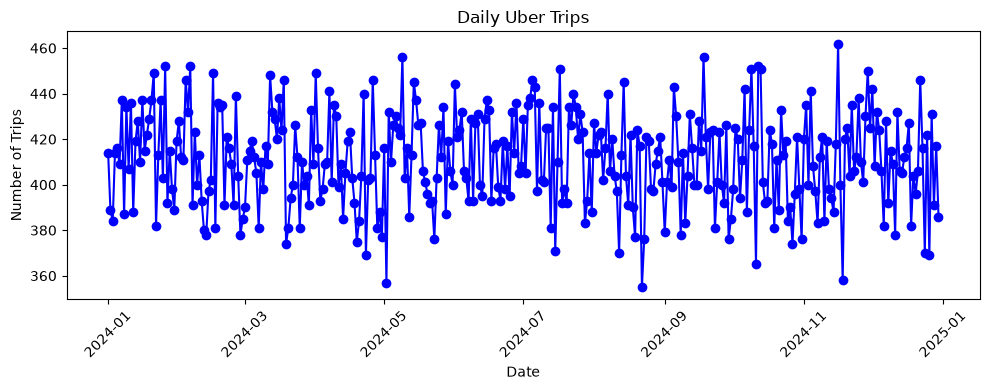

In [63]:
plt.figure(figsize=(10,4))
plt.plot(daily_trips.index, daily_trips.values, marker='o', color='blue')
plt.title("Daily Uber Trips")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* Demand is steady overall, with occasional dips likely due to holidays or weather
conditions.
* Daily bookings fluctuate between approximately 360 and 460 trips.
* No significant long-term increasing or decreasing trend is observed.
* Demand remains fairly consistent throughout the year with normal daily variations.

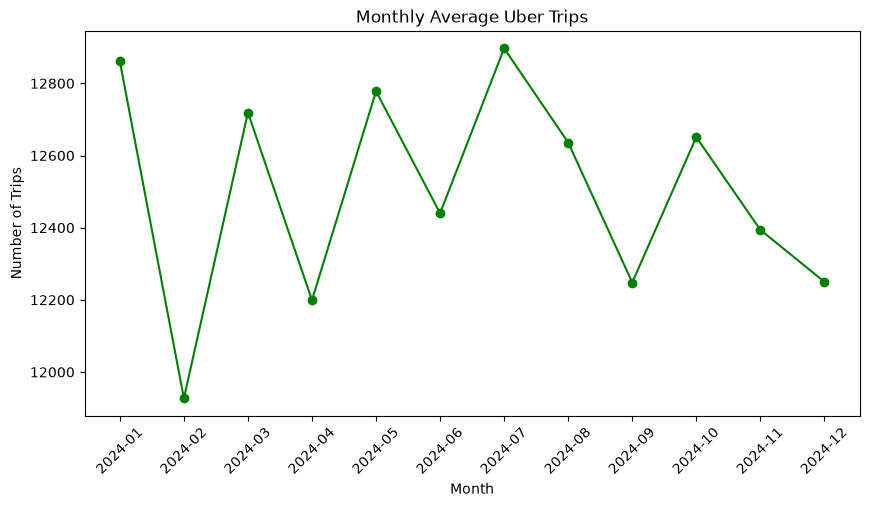

In [46]:
monthly_trips = df.groupby(df['date'].dt.to_period('M'))['booking_id'].count()
plt.figure(figsize=(10,5))
plt.plot(monthly_trips.index.astype(str), monthly_trips.values, marker='o', color='green')
plt.title("Monthly Average Uber Trips")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.show()

* Certain months show higher demand, indicating possible seasonality in ride bookings.
* Monthly trip volume remains relatively stable throughout the year.
* July records the highest average number of trips.
* February has the lowest average trip count.

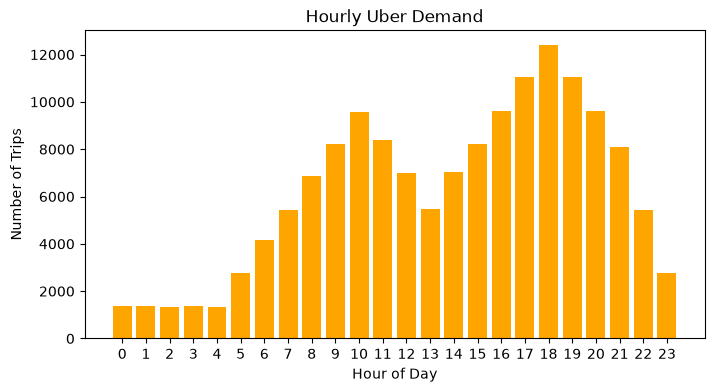

In [47]:
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce').dt.hour
hourly_trips = df.groupby('hour')['booking_id'].count()
plt.figure(figsize=(8,4))
plt.bar(hourly_trips.index, hourly_trips.values, color='orange')
plt.title("Hourly Uber Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0,24))
plt.show()


* Peak hours occur during commute times, especially in the evening.
* Ride demand is lowest during the early morning hours (12 AM–5 AM).
* Demand gradually increases after morning and reaches its highest level around 6 PM (18:00).
* Evening hours experience the highest booking volume.

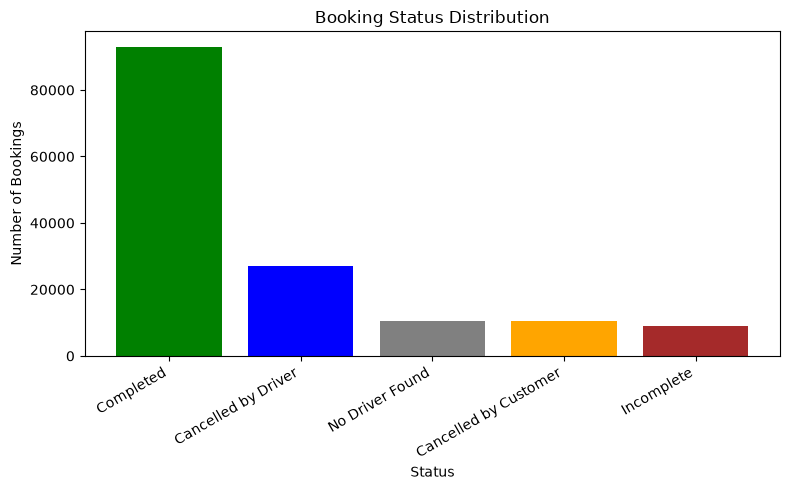

In [59]:
status_counts = df['booking_status'].value_counts()   # Count the number of bookings for each booking status
plt.figure(figsize=(8,5))
plt.bar(status_counts.index, status_counts.values, color=['green','blue','gray','orange','brown'])
plt.title("Booking Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=30, ha='right')  
plt.tight_layout()                  
plt.show()

* Driver cancellations are more frequent, highlighting a reliability issue in service.
* The majority of bookings are successfully completed, indicating efficient ride fulfillment.
* A noticeable number of rides are cancelled by drivers.

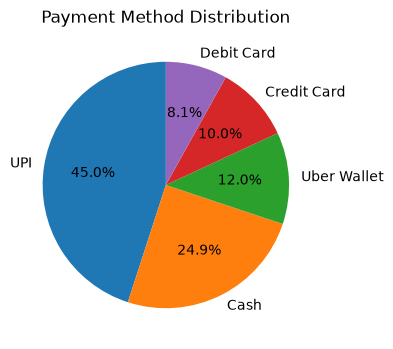

In [49]:
payment_counts = df['payment_method'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Payment Method Distribution")
plt.show()


* UPI is the most preferred payment method, accounting for 45% of all bookings.
* Cash is the second most popular payment option (24.9%), while card payments are used less frequently.
* Digital payment methods (UPI and Uber Wallet) are preferred by most customers.

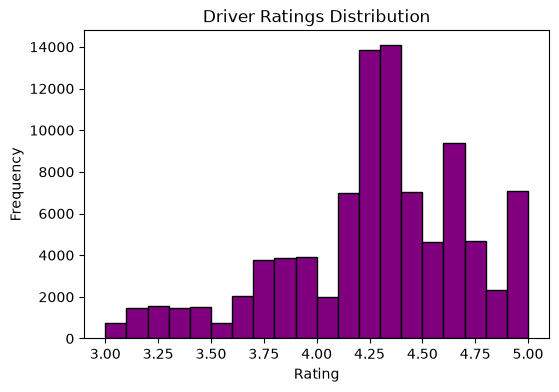

In [50]:
plt.figure(figsize=(6,4))
plt.hist(df['driver_ratings'], bins=20, color='purple', edgecolor='black')
plt.title("Driver Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

 * Most ratings are positive, but some low ratings reveal service gaps that need improvement.
 * Most driver ratings fall between 4.2 and 4.8 stars.
 * Very few drivers receive ratings below 3.5 stars.
 * Overall customer satisfaction appears to be high.

# Conclusion

This project analyzed Uber ride booking data to identify booking patterns, payment preferences, booking status, and driver ratings.

Key Findings:
- UPI is the most preferred payment method.
- Most rides are completed successfully.
- Ride demand peaks during evening hours.
- Driver ratings are generally high.
- Monthly bookings remain relatively stable.